# NER + POS Exploration
Visualize named entity distributions across cities. Run after `main.py --stage 'NER and POS'`.

In [1]:
import json
import yaml
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (13, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

In [2]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

CITIES = config['cities']
PROCESSED_DIR = Path('..') / config['paths']['processed_data']

# load all passage files
corpus = {}
for city in CITIES:
    slug = city.lower().replace(' ', '_')
    path = PROCESSED_DIR / f'{slug}_passages.json'
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            corpus[city] = json.load(f)

print(f'Loaded {len(corpus)} cities')

Loaded 20 cities


## 1. Total entities per city

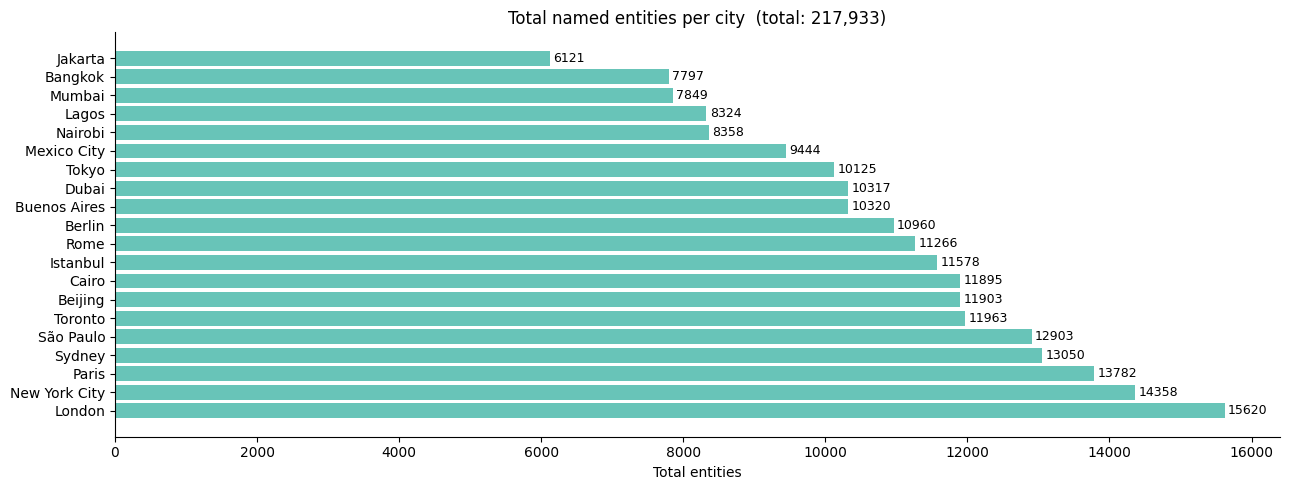

In [3]:
entity_counts = {}
for city, data in corpus.items():
    total = sum(len(p.get('entities', [])) for p in data['passages'])
    entity_counts[city] = total

cities_sorted = sorted(entity_counts, key=entity_counts.get, reverse=True)
counts_sorted = [entity_counts[c] for c in cities_sorted]

fig, ax = plt.subplots()
bars = ax.barh(cities_sorted, counts_sorted, color='#68c4b8', edgecolor='none')
ax.set_xlabel('Total entities')
ax.set_title(f'Total named entities per city  (total: {sum(counts_sorted):,})')
for bar, count in zip(bars, counts_sorted):
    ax.text(count + 50, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Entity type distribution — all cities combined

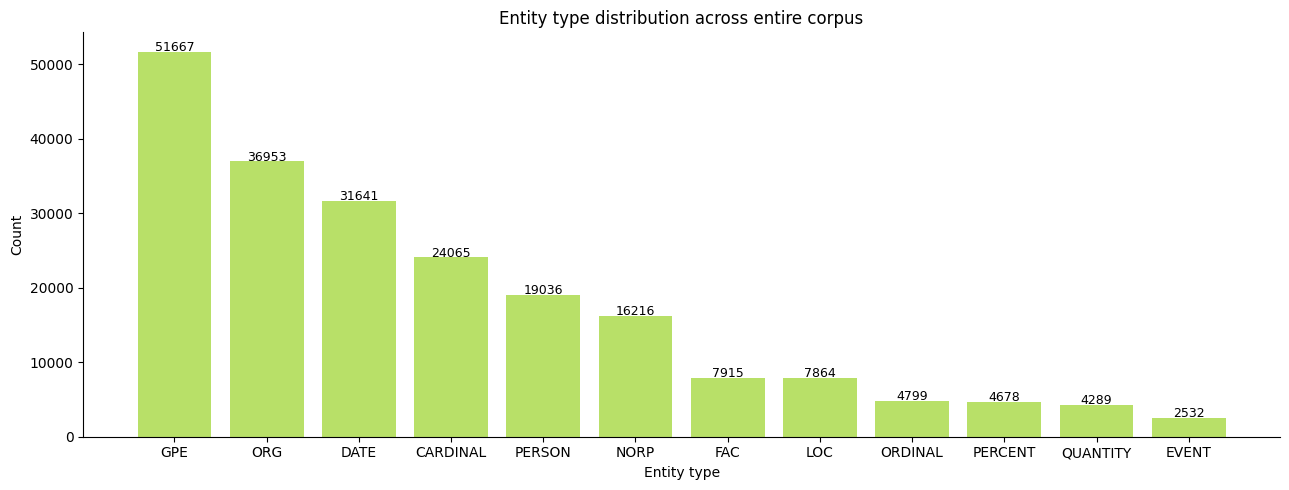

In [4]:
global_counter = Counter()
for city, data in corpus.items():
    for p in data['passages']:
        for ent in p.get('entities', []):
            global_counter[ent['label']] += 1

top_labels = global_counter.most_common(12)
labels = [l for l, _ in top_labels]
values = [v for _, v in top_labels]

fig, ax = plt.subplots()
ax.bar(labels, values, color='#b8e068', edgecolor='none')
ax.set_xlabel('Entity type')
ax.set_ylabel('Count')
ax.set_title('Entity type distribution across entire corpus')
for i, v in enumerate(values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Entity type heatmap — city vs entity type

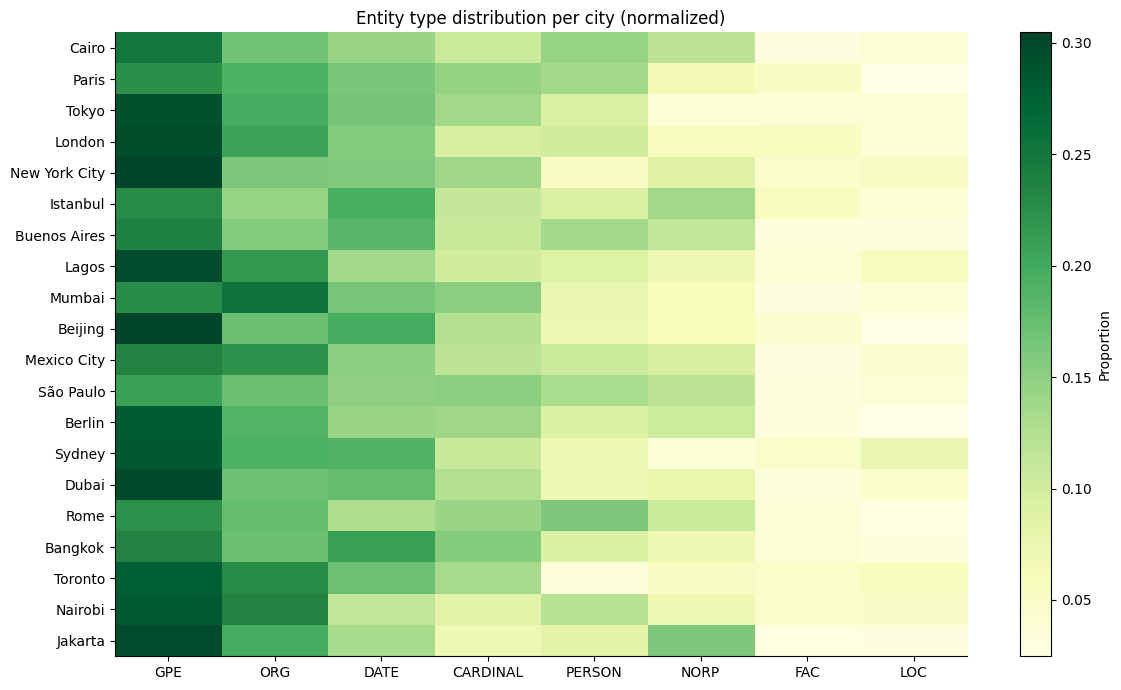

In [5]:
import numpy as np

top_entity_types = [l for l, _ in global_counter.most_common(8)]

# build matrix
city_list = list(corpus.keys())
matrix = np.zeros((len(city_list), len(top_entity_types)))

for i, city in enumerate(city_list):
    counter = Counter()
    for p in corpus[city]['passages']:
        for ent in p.get('entities', []):
            counter[ent['label']] += 1
    for j, etype in enumerate(top_entity_types):
        matrix[i][j] = counter.get(etype, 0)

# normalize per row so cities are comparable
row_sums = matrix.sum(axis=1, keepdims=True)
matrix_norm = matrix / row_sums

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(matrix_norm, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(top_entity_types)))
ax.set_xticklabels(top_entity_types)
ax.set_yticks(range(len(city_list)))
ax.set_yticklabels(city_list)
ax.set_title('Entity type distribution per city (normalized)')
plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.show()

## 4. Top named entities per city — spot check

In [6]:
def top_entities_by_type(city_data, label, n=10):
    counter = Counter()
    for p in city_data['passages']:
        for ent in p.get('entities', []):
            if ent['label'] == label:
                counter[ent['text'].strip()] += 1
    return counter.most_common(n)

# spot check Cairo, Tokyo, London, Nairobi for GPE and PERSON
sample_cities = ['Cairo', 'Tokyo', 'London', 'Nairobi']

for city in sample_cities:
    if city not in corpus:
        continue
    gpe   = top_entities_by_type(corpus[city], 'GPE', 5)
    dates = top_entities_by_type(corpus[city], 'DATE', 5)
    print(f'\n── {city} ──')
    print(f'  Top GPE  : {[e for e, _ in gpe]}')
    print(f'  Top DATE : {[e for e, _ in dates]}')


── Cairo ──
  Top GPE  : ['Cairo', 'Egypt', 'Greater Cairo', 'New Cairo', 'Heliopolis']
  Top DATE : ['today', 'annual', 'the 20th century', '2014', '2005']

── Tokyo ──
  Top GPE  : ['Tokyo', 'Japan', 'Edo', 'Shibuya', 'Haneda']
  Top DATE : ['2021', '2020', '1964', '2010', '1923']

── London ──
  Top GPE  : ['London', 'UK', 'England', 'Greater London', 'the City of London']
  Top DATE : ['2021', 'annual', 'each year', '2003', '2012']

── Nairobi ──
  Top GPE  : ['Nairobi', 'Kenya', 'Mombasa', 'Westlands', 'Kibera']
  Top DATE : ['2015', 'the year', '2007', '2005', '2016']


## 5. POS tag distribution

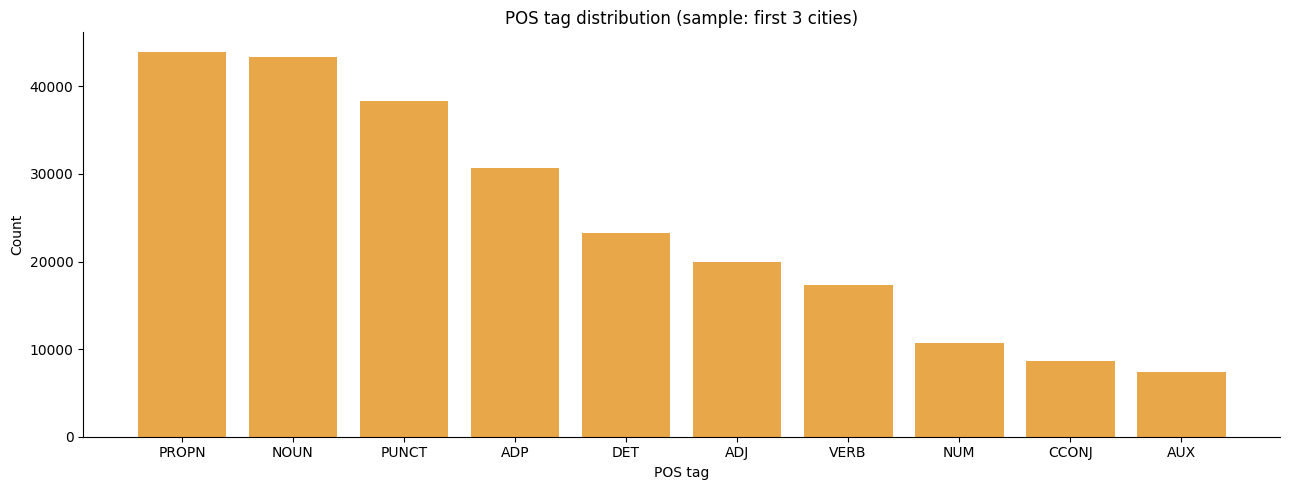

In [7]:
pos_counter = Counter()
# sample first 3 cities to keep it fast
for city in list(corpus.keys())[:3]:
    for p in corpus[city]['passages']:
        for token in p.get('pos_tags', []):
            pos_counter[token['pos']] += 1

top_pos = pos_counter.most_common(10)
pos_labels = [p for p, _ in top_pos]
pos_values = [v for _, v in top_pos]

fig, ax = plt.subplots()
ax.bar(pos_labels, pos_values, color='#e8a84a', edgecolor='none')
ax.set_xlabel('POS tag')
ax.set_ylabel('Count')
ax.set_title('POS tag distribution (sample: first 3 cities)')
plt.tight_layout()
plt.show()

## 6. Avg entities per passage by city

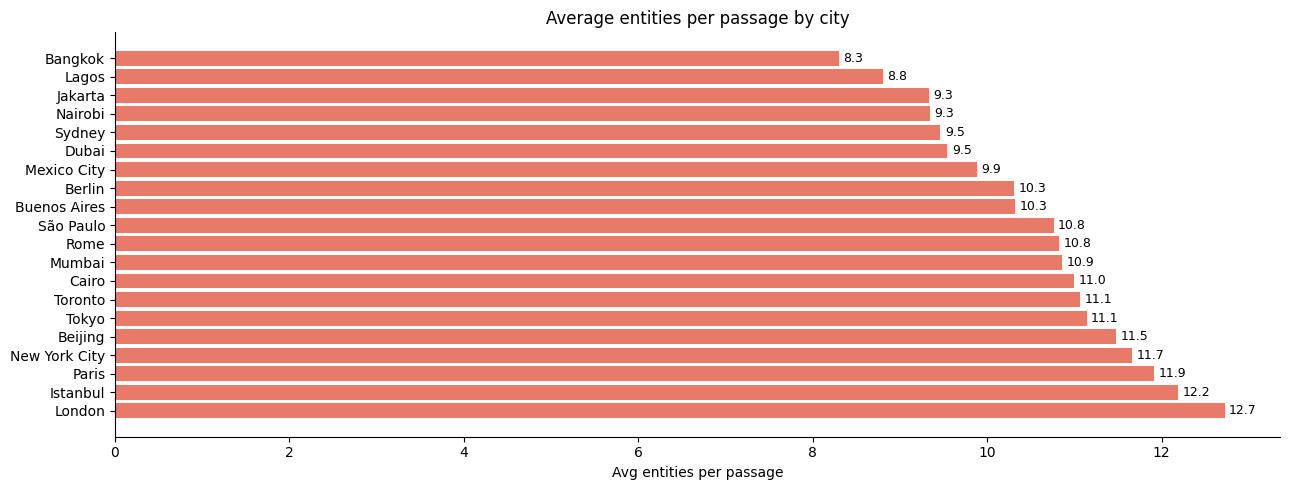

In [8]:
avg_entities = {}
for city, data in corpus.items():
    counts = [len(p.get('entities', [])) for p in data['passages']]
    avg_entities[city] = sum(counts) / len(counts) if counts else 0

cities_s = sorted(avg_entities, key=avg_entities.get, reverse=True)
avgs_s   = [avg_entities[c] for c in cities_s]

fig, ax = plt.subplots()
ax.barh(cities_s, avgs_s, color='#e87a6a', edgecolor='none')
ax.set_xlabel('Avg entities per passage')
ax.set_title('Average entities per passage by city')
for bar, val in zip(ax.patches, avgs_s):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()